## AuxTel Mount fails - 11-Mar-21

In this notebook, investigate mount in position error from 10-Mar-21

In [1]:
import sys, time, os, asyncio

from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.time import Time, TimeDelta
from lsst_efd_client import EfdClient


In [2]:
# Get EFD client and bring in Lupton's unpacking code
client = EfdClient('summit_efd')

def merge_packed_time_series(packed_dataframe, base_field, stride=1, 
                             ref_timestamp_col="cRIO_timestamp", internal_time_scale="tai"):
    """Select fields that are time samples and unpack them into a dataframe.
            Parameters
            ----------
            packedDF : `pandas.DataFrame`
                packed data frame containing the desired data
            base_field :  `str`
                Base field name that will be expanded to query all
                vector entries.
            stride : `int`, optional
                Only use every stride value when unpacking.  Must be a factor
                of the number of packed values.
                (1 by default)
            ref_timestamp_col : `str`, optional
                Name of the field name to use to assign timestamps to unpacked
                vector fields (default is 'cRIO_timestamp').
            internal_time_scale : `str`, optional
                Time scale to use when converting times to internal formats
                ('tai' by default). Equivalent to EfdClient.internal_scale
        Returns
            -------
            result : `pandas.DataFrame`
                A `pandas.DataFrame` containing the results of the query.
            """
    
    packed_fields = [k for k in packed_dataframe.keys() if k.startswith(base_field)]
    packed_fields = sorted(packed_fields, key=lambda k: int(k[len(base_field):]))  # sort by pack ID
    npack = len(packed_fields)
    if npack%stride != 0:
        raise RuntimeError(f"Stride must be a factor of the number of packed fields: {stride} v. {npack}")
    packed_len = len(packed_dataframe)
    n_used = npack//stride   # number of raw fields being used
    output = np.empty(n_used*packed_len)
    times = np.empty_like(output, dtype=packed_dataframe[ref_timestamp_col][0])
    
    if packed_len == 1:
        dt = 0
    else:
        dt = (packed_dataframe[ref_timestamp_col][1] - packed_dataframe[ref_timestamp_col][0])/npack
    for i in range(0, npack, stride):
        i0 = i//stride
        output[i0::n_used] = packed_dataframe[f"{base_field}{i}"]
        times[i0::n_used] = packed_dataframe[ref_timestamp_col] + i*dt
     
    timestamps = Time(times, format='unix', scale=internal_time_scale).datetime64
    return pd.DataFrame({base_field:output, "times":times}, index=timestamps)

In [3]:
# These are for finding the timestamps of the scripts
start = Time('2021-03-10T20:15:00') #this is UTC
end = Time('2021-03-10T23:35:00')

In [4]:
timestamp = f"time >= '{start}+00:00' AND time <= '{end}+00:00'"

query = f'SELECT "heartbeat" FROM "efd"."autogen"."lsst.sal.Script.logevent_heartbeat" WHERE {timestamp}'

script_time_frame = await client.influx_client.query(query)
# script_time_frame = await client.select_time_series('lsst.sal.Script.logevent_heartbeat', 'heartbeat, ScriptID', 
#                                      start.tai, end.tai)

In [6]:
#time_start = f"{timestamp.index[0]}".replace(" ", "T")
#time_end = f"{timestamp.index[-1]}".replace(" ", "T")
#timestamp = f"time >= '{time_start}' AND time <= '{time_end}'"
query = f'SELECT "inPosition" FROM "efd"."autogen"."lsst.sal.ATMCS.logevent_allAxesInPosition" WHERE {timestamp} and inPosition = true'

inPosition = await client.influx_client.query(query)
print(start, end)
print(len(inPosition))

# cmd,  stopTracking, startTracking

2021-03-10T20:15:00.000 2021-03-10T23:35:00.000
9


In [7]:
time_inPosition = Time(inPosition.index[-1])
print(inPosition, time_inPosition.tai)
print(start, end)

                                  inPosition
2021-03-10 21:06:11.425000+00:00        True
2021-03-10 21:14:48.424000+00:00        True
2021-03-10 21:15:07.028000+00:00        True
2021-03-10 21:16:11.320000+00:00        True
2021-03-10 21:16:43.170000+00:00        True
2021-03-10 21:25:43.823000+00:00        True
2021-03-10 21:29:04.172000+00:00        True
2021-03-10 22:30:07.624000+00:00        True
2021-03-10 22:49:30.581000+00:00        True 2021-03-10 22:50:07.581000
2021-03-10T20:15:00.000 2021-03-10T23:35:00.000


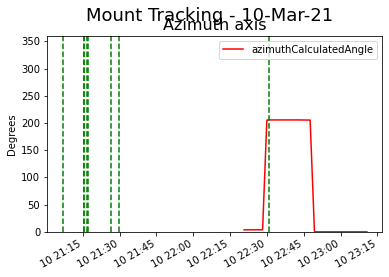

In [24]:
# Get the data
index = 7
time_inPosition = Time(inPosition.index[index])
inPs = []
for i in range(8):
    inPs.append(Time(inPosition.index[i]).tai)

ts = time_inPosition.tai + TimeDelta(-600, format='sec')
te = time_inPosition.tai + TimeDelta(2400, format='sec')

mount_position = await client.select_time_series("lsst.sal.ATMCS.mount_AzEl_Encoders", ['*'],
                                          ts, te)

az = merge_packed_time_series(mount_position, 'azimuthCalculatedAngle', stride=1)

# Plot it
fig = plt.figure()#figsize = (16,6))
plt.suptitle(f"Mount Tracking - 10-Mar-21", fontsize = 18)
# Azimuth axis
plt.subplot(1,1,1)
ax1 = az['azimuthCalculatedAngle'].plot(legend=True, color='red')
ax1.set_title("Azimuth axis", fontsize=16)
for inP in inPs:
    ax1.axvline(inP.isot, color="green", linestyle="--")
#ax1.axvline(te.isot, color="red", linestyle="--")
#ax1.set_xticks([])
ax1.set_ylim(0, 360)
ax1.set_ylabel("Degrees")
plt.savefig(f"/home/craiglagegit/DATA/InPosition_Failure_10Mar21.pdf")


In [ ]:
len(az) / 6000